In [22]:
%pip install numpy matplotlib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
plt.rcParams['figure.figsize'] = (12, 8)

Note: you may need to restart the kernel to use updated packages.


In [23]:
L = 40
T0, Tf = 5.0, 0.01
ANN_STEPS = 2000
CMAP = ListedColormap(["red", "blue"])

# Ricerca di minimi di funzione
In questa relazione vogliamo studiare il problema della ricerca di minimi di funzione. Data una configurazione $\mathcal{C}$, vogliamo minimizzare una funzione $E(\mathcal{C})$, detta **funzione di costo**. Trascurando casi banali o didattici, nei contesti reali queste funzioni possono presentare molti minimi locali, cioè punti in cui modificando la configurazione si ottiene un aumento della funzione di costo che però non rappresentano il minimo globale.

Il metodo più immediato per cercare i minimi è chiamato **Greedy** e consiste in un'implementazione dell'algoritmo di Metropolis in cui si accettano passi solo quando abbassano, o mantengono uguale, l'energia. Il problema di questo metodo è che una volta entrato in un minimo locale non riesce più ad uscirne.

Per avere dei risultati migliori si prende in prestito un processo usato in metallurgia, chiamato **Annealing**, che consiste nell'utilizzare l'algoritmo di Metropolis in cui la temperatura diminuisce nel tempo. In questo modo il sistema ha la possibilità di esplorare varie configurazione quando si trova ad alta temperatura, trovare il minimo globale grazie al lento raffreddamento e rimanere nel minimo globale quando la temperatura è bassa.

La scelta della temperatura ad un determinato passo è effettuata mediante una *schedule*. Le schedule che verranno utilizzato in questa relazione sono:
- schedule **lineare**, $$T(t)=T_0 - (T_0 - T_f) \cdot \frac{t}{t_{max}},$$ con $T_0$ temperatura iniziale (alta) e $T_f$ temperatura finale (bassa);
- schedule **esponenziale**, $$T(t)=T_0 \cdot \left(\frac{T_f}{T_0}\right)^{t/t_{max}}=T_0 \cdot \alpha^t,$$ con $\alpha=(T_f / T_0)^{1/t_{max}}$.

# Spin glass
Simuleremo un modello di Ising in cui gli accoppiamenti fra spin non sono più costanti ma sono pseudo-casuali. La hamiltoniana diventa: $$H=-\sum_{\langle i,j\rangle}J_{ij}S_i S_j$$ e gli elementi di matrice $J_{ij}$ assumono valori $\pm1$ con uguale probabilità.

Un fenomeno che si instaura in questa variante è quello della **frustrazione**: non esiste una configurazione che soddisfi il minimo di energia per tutti gli spin, cioè non è possibile avere una configurazione ferromagnetica in cui tutti gli spin sono allineati. Infatti nello stato di minima energia non si ha una magnetizzazione unitaria come nel caso del modello classico: $$|M|/N\approx0.$$

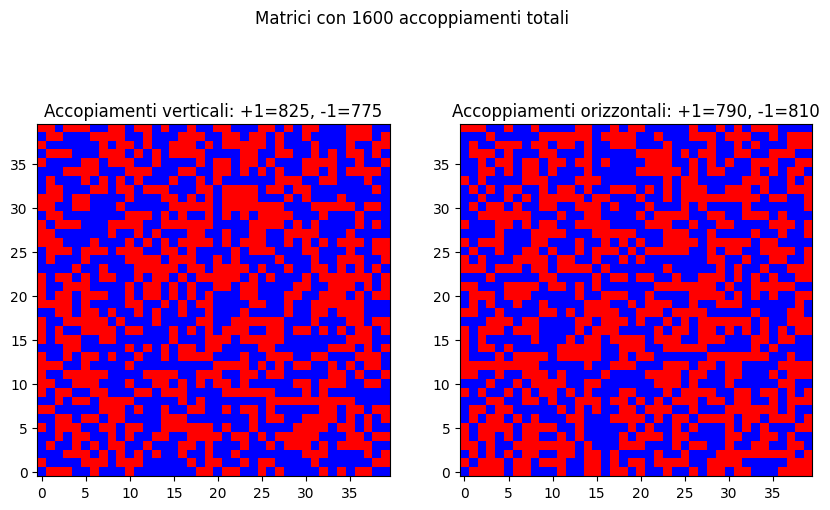

In [24]:
rng = np.random.default_rng(seed=75)
j_ver = rng.choice([-1,1], size=(L,L))
j_hor = rng.choice([-1,1], size=(L,L))
j_ver_up = 0
j_hor_up = 0
for i in range(L):
    for j in range(L):
        if j_ver[i,j] == 1:
            j_ver_up += 1

for i in range(L):
    for j in range(L):
        if j_hor[i,j] == 1:
            j_hor_up += 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6))
ax1.imshow(j_ver, origin="lower", cmap=CMAP)
ax1.set_title(f"Accopiamenti verticali: +1={j_ver_up}, -1={L**2 - j_ver_up}")
ax2.imshow(j_hor, origin="lower", cmap=CMAP)
ax2.set_title(f"Accoppiamenti orizzontali: +1={j_hor_up}, -1={L**2 - j_hor_up}")
plt.suptitle(f"Matrici con {L**2} accoppiamenti totali")
plt.show()

In [25]:
def greedy_mc(lattice, checkerboard, j_ver, j_hor, T=0.0):
    kb = 1.0
    for s in [checkerboard, ~checkerboard]:
        # sto assumendo che nella posizione i,j l'accoppiamento in basso e a destra sia dato 
        # da j_ver[i,j] e j_hor[i,j], mentre in alto e a sinistra prendo i valori j_ver[i,j-1] e j_hor[i-1,j]
        neig_j_sum = (
            np.roll(lattice, shift=1, axis=0) * np.roll(j_ver, shift=1, axis=0)
            + np.roll(lattice, shift=-1, axis=0) * j_ver
            + np.roll(lattice, shift=1, axis=1) * np.roll(j_hor, shift=1, axis=1)
            + np.roll(lattice, shift=-1, axis=1) * j_hor
        )
        de_s = 2 * lattice[s] * neig_j_sum[s]
        accept = de_s <= 0
        lattice[s] = np.where(accept, -lattice[s], lattice[s])

def metropolis(lattice, even_mask, j_ver, j_hor, T=0.5):
    kb = 1.0
    for s in [even_mask, ~even_mask]:
        neig_j_sum = (
            np.roll(lattice, shift=1, axis=0) * np.roll(j_ver, shift=1, axis=0)
            + np.roll(lattice, shift=-1, axis=0) * j_ver
            + np.roll(lattice, shift=1, axis=1) * np.roll(j_hor, shift=1, axis=1)
            + np.roll(lattice, shift=-1, axis=1) * j_hor
        )
        de_s = 2 * lattice[s] * neig_j_sum[s]
        prob = np.exp(-de_s/(kb*T))
        accept = (de_s <= 0) | (rng.random(de_s.shape) < prob)
        lattice[s] = np.where(accept, -lattice[s], lattice[s])

In [26]:
def energia(lattice, j_ver, j_hor):
    # sto facendo la stessa assunzione precedente e calcolo solo il valore in basso e a destra
    # per non dividere per due il risultato finale
    neig_j_sum = (
        np.roll(lattice, shift=-1, axis=0) * j_ver
        + np.roll(lattice, shift=-1, axis=1) * j_hor
    )
    tot_en = -np.sum(lattice * neig_j_sum)
    
    return tot_en

def magnetization(lattice):
    return np.abs(np.sum(lattice))

In [27]:
run = 10
spin_energies = np.zeros(run)
spin_magns = np.zeros(run)

for i in range(run):
    lattice = np.random.choice([-1,1], size=(L, L))
    checkerboard = np.zeros((L,L), dtype=bool)
    checkerboard[::2, ::2] = True
    checkerboard[1::2, 1::2] = True
    for _ in range(ANN_STEPS):
        greedy_mc(lattice, checkerboard, j_ver, j_hor)
    
    spin_energies[i] = energia(lattice, j_ver, j_hor) / L**2
    spin_magns[i] = magnetization(lattice) / L**2

spin_errs = np.std(spin_energies, ddof=1) / np.sqrt(run)

In [28]:
print(f"Energie raggiunte: {spin_energies}")
print(f"Energia media: {np.mean(spin_energies)}")
print(f"Std.dev.: +-{np.std(spin_energies, ddof=1) / np.sqrt(run)}")
print(f"Energia minima: {np.min(spin_energies)}")
print(f"Energia massima: {np.max(spin_energies)}")
print(f"Magnetizzazione media: {np.mean(spin_magns)}")

Energie raggiunte: [-1.35875 -1.36125 -1.36375 -1.36125 -1.36375 -1.36375 -1.35625 -1.35875
 -1.35625 -1.35375]
Energia media: -1.3597499999999998
Std.dev.: +-0.0011303883305208867
Energia minima: -1.36375
Energia massima: -1.35375
Magnetizzazione media: 0.022


In [29]:
run = 10
energies_metro = np.zeros(run)
magns_metro = np.zeros(run)

for i in range(run):
    lattice = np.random.choice([-1,1], size=(L, L))
    checkerboard = np.zeros((L,L), dtype=bool)
    checkerboard[::2, ::2] = True
    checkerboard[1::2, 1::2] = True
    for _ in range(ANN_STEPS):
        metropolis(lattice, checkerboard, j_ver, j_hor)
    
    energies_metro[i] = energia(lattice, j_ver, j_hor) / L**2
    magns_metro[i] = magnetization(lattice) / L**2

metro_errs = np.std(energies_metro, ddof=1) / np.sqrt(run)

In [30]:
print(f"Energie raggiunte: {energies_metro}")
print(f"Energia media: {np.mean(energies_metro)}")
print(rf"$\sigma$: +-{np.std(energies_metro, ddof=1) / np.sqrt(run)}")
print(f"Energia minima: {np.min(energies_metro)}")
print(f"Energia massima: {np.max(energies_metro)}")
print(f"Magnetizzazione media: {np.mean(magns_metro)}")

Energie raggiunte: [-1.37125 -1.37125 -1.37625 -1.37125 -1.37875 -1.38125 -1.37875 -1.38125
 -1.36625 -1.37125]
Energia media: -1.37475
$\sigma$: +-0.0016329931618554497
Energia minima: -1.38125
Energia massima: -1.36625
Magnetizzazione media: 0.020624999999999998


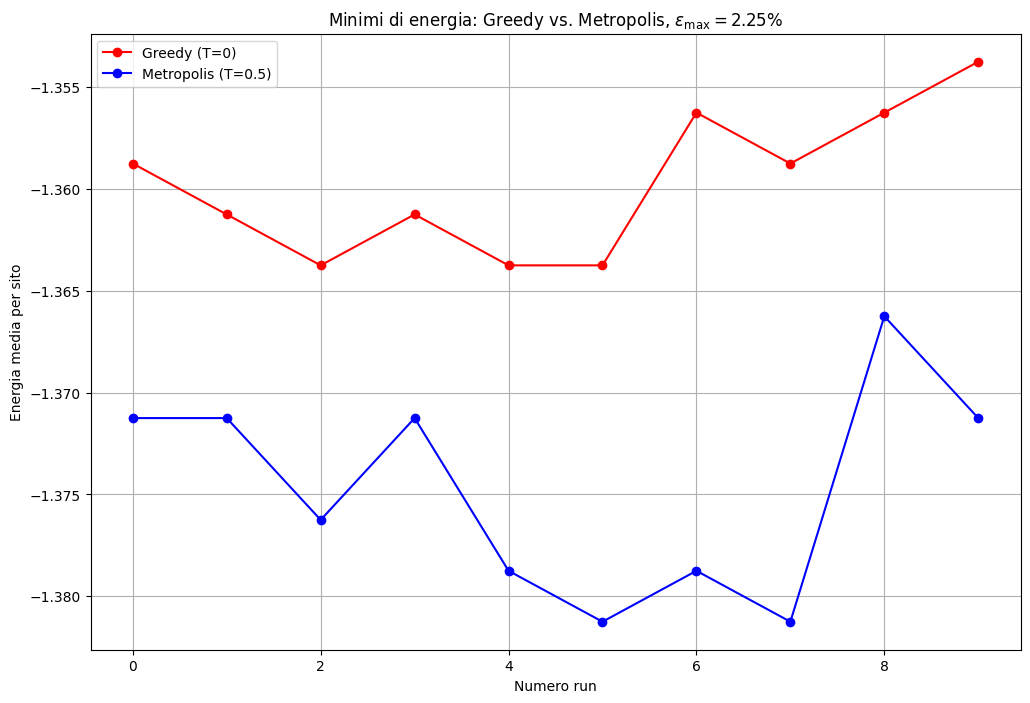

In [31]:
plt.plot(spin_energies, "-o", color="red", label="Greedy (T=0)")
plt.plot(energies_metro, "-o", color="blue", label="Metropolis (T=0.5)")
plt.xlabel("Numero run")
plt.ylabel("Energia media per sito")
plt.title(rf"Minimi di energia: Greedy vs. Metropolis, $\epsilon_\max={round(np.max(np.abs(energies_metro - spin_energies))*100,2)}\%$")
plt.grid()
plt.legend()
plt.show()

Nella seguente tabella vengono confrontati i valori massimi e minimi delle energie trovate con i metodi Greedy e Metropolis. Inoltre, sono riportate le energie medie con le deviazioni standard e le magnetizzazioni medie. Nel grafico precedente si nota che le differenze in energia non sono marcate: la discrepanza massima è pari al $3\%$.

||Greedy (T=0)|Metropolis (T=0.5)|
|---|---|---|
|En. max|-1.354|-1.366|
|En. min|-1.364|-1.381|
|En. media|-1.360|-1.375|
|$\sigma$|$\pm$0.001|$\pm$0.002|
|Magn. media|0.022|0.021|

In [32]:
# schedule lineare e esponenziale
lin_annealing = np.linspace(T0, Tf, ANN_STEPS)
exp_annealing = np.logspace(np.log10(T0), np.log10(Tf), ANN_STEPS)

lin_ann_en = np.zeros(ANN_STEPS)
exp_ann_en = np.zeros(ANN_STEPS)
lin_lattice = np.random.choice([-1,1], size=(L, L))
exp_lattice = np.random.choice([-1,1], size=(L, L))
checkerboard = np.zeros((L,L), dtype=bool)
checkerboard[::2, ::2] = True
checkerboard[1::2, 1::2] = True

for i in range(ANN_STEPS):
    metropolis(lin_lattice, checkerboard, j_ver, j_hor, T=lin_annealing[i])
    metropolis(exp_lattice, checkerboard, j_ver, j_hor, T=exp_annealing[i])
    lin_ann_en[i] = energia(lin_lattice, j_ver, j_hor) / L**2
    exp_ann_en[i] = energia(exp_lattice, j_ver, j_hor) / L**2

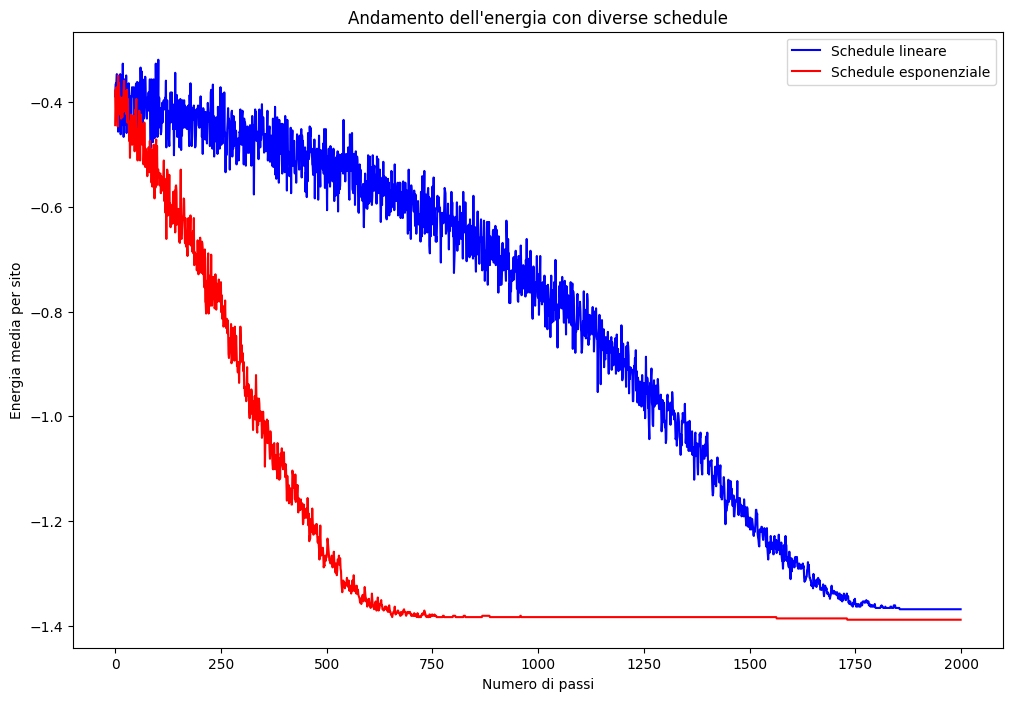

In [33]:
lin_color, exp_color = "blue", "red"
plt.plot(lin_ann_en, color=lin_color, label="Schedule lineare")
plt.plot(exp_ann_en, color=exp_color, label="Schedule esponenziale")
plt.xlabel("Numero di passi")
plt.ylabel("Energia media per sito")
plt.legend()
plt.title("Andamento dell'energia con diverse schedule")
plt.show()

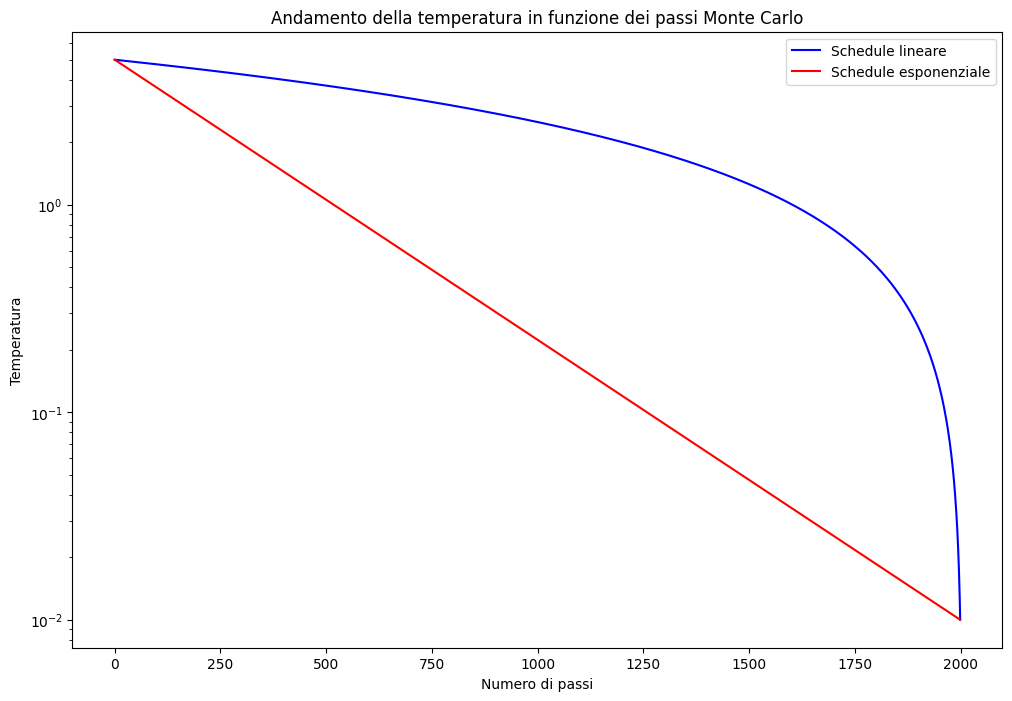

In [51]:
plt.plot(lin_annealing, color=lin_color, label="Schedule lineare")
plt.plot(exp_annealing, color=exp_color, label="Schedule esponenziale")
plt.yscale("log")
plt.xlabel("Numero di passi")
plt.ylabel("Temperatura")
plt.legend()
plt.title("Andamento della temperatura in funzione dei passi Monte Carlo")
plt.show()

In [47]:
run = 10
ANN_STEPS = 2000
lin_annealing = np.linspace(T0, Tf, ANN_STEPS)
exp_annealing = np.logspace(np.log10(T0), np.log10(Tf), ANN_STEPS)
lin_ann_en = np.zeros(run)
exp_ann_en = np.zeros(run)

checkerboard = np.zeros((L,L), dtype=bool)
checkerboard[::2, ::2] = True
checkerboard[1::2, 1::2] = True

for i in range(run):
    initial = np.random.choice([-1,1], size=(L, L))
    # creo delle copie per avere le stesse condizioni iniziali
    lin_lattice = initial.copy()
    exp_lattice = initial.copy()
    for j in range(ANN_STEPS):
        metropolis(lin_lattice, checkerboard, j_ver, j_hor, T=lin_annealing[j])
        metropolis(exp_lattice, checkerboard, j_ver, j_hor, T=exp_annealing[j])
    lin_ann_en[i] = energia(lin_lattice, j_ver, j_hor) / L**2
    exp_ann_en[i] = energia(exp_lattice, j_ver, j_hor) / L**2

lin_errs = np.std(lin_ann_en, ddof=1) / np.sqrt(run)
exp_errs = np.std(exp_ann_en, ddof=1) / np.sqrt(run)

In [48]:
print(f"Media energia: LINEARE={np.mean(lin_ann_en)}, EXP={np.mean(exp_ann_en)}")
print(f"Std.dev: LINEARE={np.std(lin_ann_en, ddof=1) / np.sqrt(run)}, EXP={np.std(exp_ann_en, ddof=1) / np.sqrt(run)}")

Media energia: LINEARE=-1.37825, EXP=-1.38
Std.dev: LINEARE=0.0015723301886761123, EXP=0.0012500000000000076


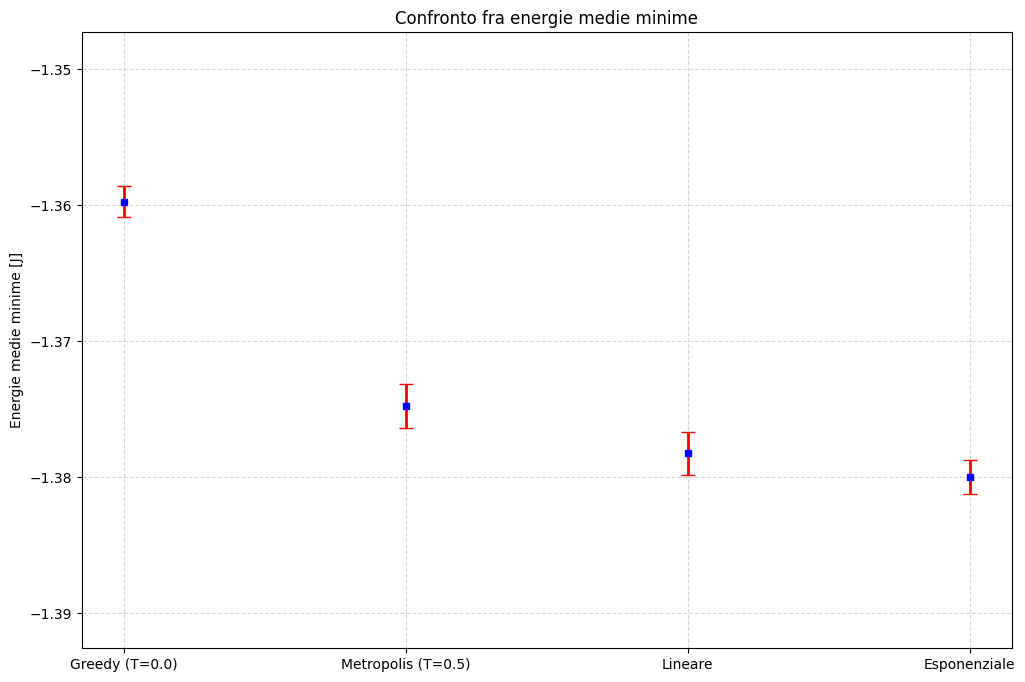

In [50]:
mean_engs = np.array([np.mean(spin_energies), np.mean(energies_metro), np.mean(lin_ann_en), np.mean(exp_ann_en)])
labels = ["Greedy (T=0.0)", "Metropolis (T=0.5)", "Lineare", "Esponenziale"]
errs = np.array([spin_errs, metro_errs, lin_errs, exp_errs])
y_min, y_max = np.min(mean_engs - errs), np.max(mean_engs + errs)
margin = (y_max - y_min) * 0.5

plt.errorbar(
    labels, 
    mean_engs, 
    yerr=errs, 
    fmt="s", 
    color="blue", 
    ecolor="red", 
    capsize=5, 
    elinewidth=2, 
    markersize=5)
plt.ylabel("Energie medie minime [J]")
plt.ylim(y_min - margin, y_max + margin)
plt.grid(linestyle="--", alpha=0.5)
plt.title("Confronto fra energie medie minime")
plt.show()

Notiamo come l'Annealing, sia lineare che esponenziale, ottiene energie sensibilmente inferiori rispetto al metodo Greedy. Questo accade perché il metodo Greedy converge velocemente a un minimo quasi sempre locale e, rifiutando variazioni positive di energia, non riesce più ad uscirne. Al contrario, la lenta riduzione dell'Annealing consente al sistema di esplorare l'intero spazio degli stati e di raggiungere il minimo globale.

In [38]:
print(f"Greedy. Media: {np.mean(spin_energies)}, minima: {np.min(spin_energies)}, std: {np.std(spin_energies, ddof=1) / np.sqrt(run)}")
print(f"Metropolis. Media: {np.mean(energies_metro)}, minima: {np.min(energies_metro)}, std: {np.std(energies_metro, ddof=1) / np.sqrt(run)}")
print(f"Schedule lineare. Media: {np.mean(lin_ann_en)}, minima: {np.min(lin_ann_en)}, std: {np.std(lin_ann_en, ddof=1) / np.sqrt(run)}")
print(f"Schedule esponenziale. Media: {np.mean(exp_ann_en)}, minima: {np.min(exp_ann_en)}, std: {np.std(exp_ann_en, ddof=1) / np.sqrt(run)}")

Greedy. Media: -1.3597499999999998, minima: -1.36375, std: 0.0011303883305208867
Metropolis. Media: -1.37475, minima: -1.38125, std: 0.0016329931618554497
Schedule lineare. Media: -1.373, minima: -1.38125, std: 0.001238839062276549
Schedule esponenziale. Media: -1.379, minima: -1.38625, std: 0.0017260262647673288


|Metodo|$E/N$ media|$E/N$ minima|Deviazione standard|
|---|---|---|---|
|Greedy ($T=0.0$)|-1.360|-1.364|0.001|
|Metropolis ($T=0.5$)|-1.375|-1.381|0.002|
|Lineare|-1.373|-1.381|0.001|
|Esponenziale|-1.379|-1.386|0.002|

In [44]:
run = 4
ann_steps = [200, 500, 1000, 2000]
exp_energies = np.zeros(len(ann_steps))
std_devs = np.zeros(len(ann_steps))

for idx, step in enumerate(ann_steps):
    exp_annealing = np.logspace(np.log10(T0), np.log10(Tf), step)
    energies = np.zeros(run)
    for i in range(run):
        lattice = np.random.choice([-1,1], size=(L,L))
        for j in range(step):
            metropolis(lattice, checkerboard, j_ver, j_hor, T=exp_annealing[j])
        energies[i] = energia(lattice, j_ver, j_hor) / L**2
    exp_energies[idx] = np.mean(energies)
    std_devs[idx] = np.std(energies, ddof=1) / np.sqrt(run)

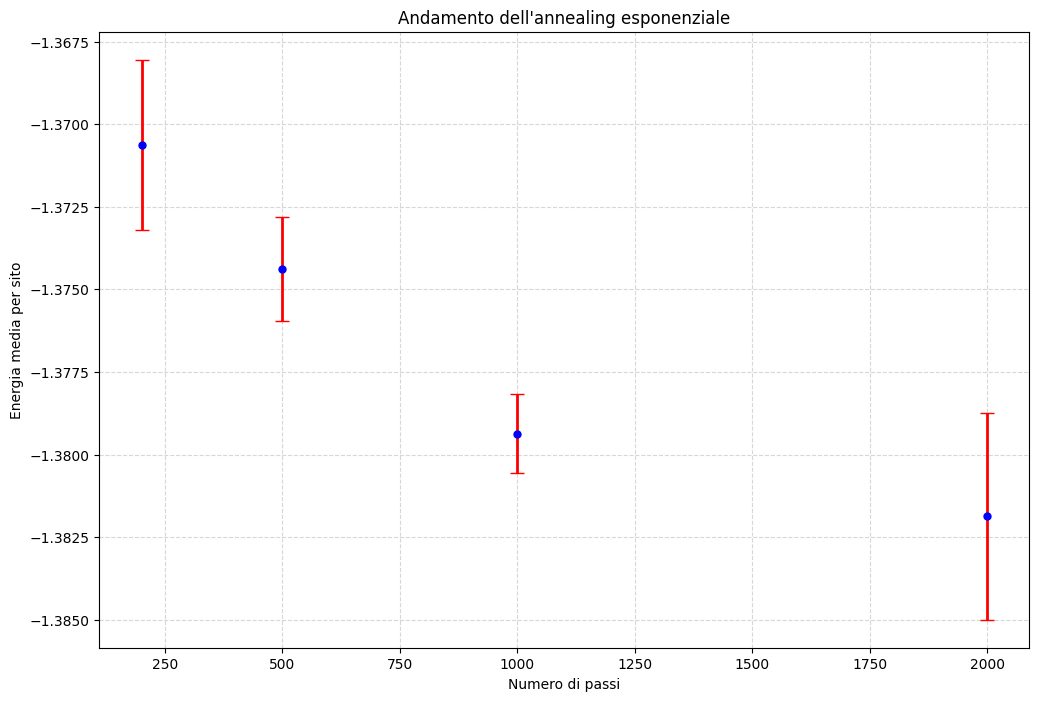

In [45]:
plt.errorbar(
    ann_steps, 
    exp_energies, 
    yerr=std_devs, 
    fmt="o", 
    color="blue", 
    ecolor="red",
    capsize=5, 
    elinewidth=2, 
    markersize=5)
plt.xlabel("Numero di passi")
plt.ylabel("Energia media per sito")
plt.title("Andamento dell'annealing esponenziale")
plt.grid(linestyle="--", alpha=0.5)
plt.show()

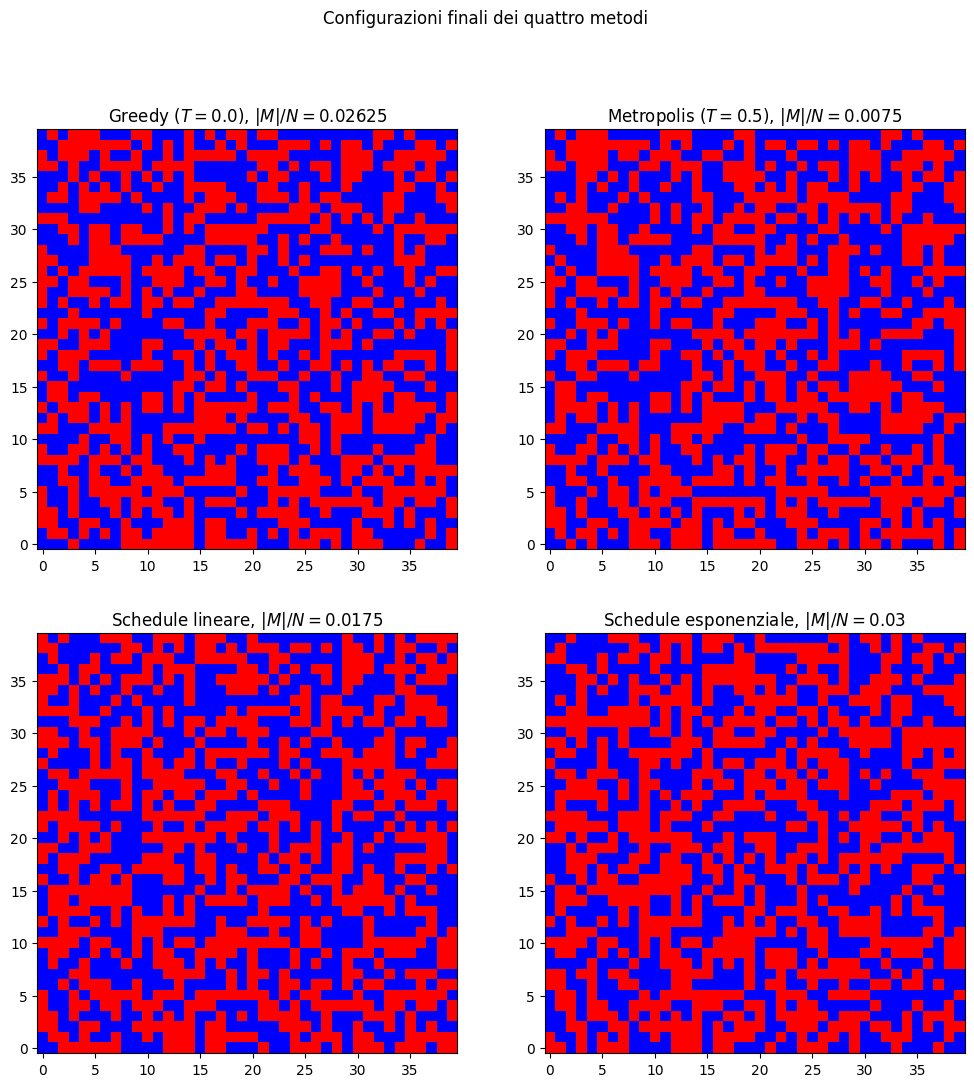

In [41]:
initial_lattice = np.random.choice([-1,1], size=(L,L))
greedy_lattice = initial_lattice.copy()
metro_lattice = initial_lattice.copy()
linear_lattice = initial_lattice.copy()
exp_lattice = initial_lattice.copy()

ANN_STEPS = 2000
fig, ((grd, met), (lin, exp)) = plt.subplots(2, 2, figsize=(12,12))
for i in range(ANN_STEPS):
    greedy_mc(greedy_lattice, checkerboard, j_ver, j_hor)
    metropolis(metro_lattice, checkerboard, j_ver, j_hor)
    metropolis(linear_lattice, checkerboard, j_ver, j_hor, T=lin_annealing[i])
    metropolis(exp_lattice, checkerboard, j_ver, j_hor, T=exp_annealing[i])

grd.imshow(greedy_lattice, origin="lower", cmap=CMAP)
grd.set_title(rf"Greedy ($T=0.0$), $|M|/N={magnetization(greedy_lattice) / L**2}$")
met.imshow(metro_lattice, origin="lower", cmap=CMAP)
met.set_title(rf"Metropolis ($T=0.5$), $|M|/N={magnetization(metro_lattice) / L**2}$")
lin.imshow(linear_lattice, origin="lower", cmap=CMAP)
lin.set_title(rf"Schedule lineare, $|M|/N={magnetization(linear_lattice) / L**2}$")
exp.imshow(exp_lattice, origin="lower", cmap=CMAP)
exp.set_title(rf"Schedule esponenziale, $|M|/N={magnetization(exp_lattice) / L**2}$")
plt.suptitle("Configurazioni finali dei quattro metodi")
plt.show()

In questo ultimo grafico è possibile notare che, nonostante le temperature siano molto basse, il sistema non raggiunga una configurazione ferromagnetica ($\langle M\rangle/N=\pm1$) a causa del fenomeno della frustrazione introdotto dalla non costanza dei valori di accoppiamento fra spin adiacenti. Il sistema non trova una configurazione che minimizzi l'energia soddisfacendo contemporaneamente tutti gli spin.